# 02 – Split Manifest generálás
**Szerző:** Magda Ferenc (U5O0BB)  
**Projekt:** Gitár akkord felismerő szoftver gépi látással  
**Notebook célja:** Reprodukálható train / validation / test felosztás létrehozása
az `all/` mappából, CSV manifest fájl formájában.

**Stratégia:** manifest-alapú split – az eredeti fájlstruktúra érintetlen marad,
a `data/split_manifest.csv` határozza meg, melyik kép melyik splitbe tartozik.

---
*Tartalomjegyzék*
1. Könyvtárak és konfiguráció
2. Inventoryzáció – `all/` mappa átnézése
3. Stratified split (70 / 15 / 15)
4. Manifest CSV mentése
5. Ellenőrzés & vizualizáció
6. Összefoglaló és következő lépések

<a id='1'></a>
## 1. Könyvtárak és konfiguráció

### Elméleti háttér: Reprodukálhatóság és véletlenszám-magok

A gépi tanulási kísérletek reprodukálhatósága kulcsfontosságú: ugyanazon adatból, ugyanazon kóddal ugyanazt az eredményt kell kapni.

**`RANDOM_SEED`:** A pszeudovéletlen-szám generátor (PRNG) inicializálási értéke. A NumPy `default_rng(seed)` és az sklearn véletlenszám-generátorai determinisztikus kimenetet adnak, ha ugyanazt a seed-et kapják. Fontos, hogy:
- A seed egyetlen helyen legyen definiálva (`config` / notebook elején)
- Minden véletlenszerű műveletnél (szplit, shuffle) átadjuk

**`numpy.random.default_rng(seed)`**: Az ajánlott modern NumPy PRNG, amely a PCG64 algoritmust használja. Statisztikailag minőségibb, mint a régi `np.random.seed()`.

**`sklearn.model_selection`**: A `StratifiedShuffleSplit` és más osztók automatikusan öröklik a seed-et, ha `random_state=RANDOM_SEED` paraméterrel inicializáljuk. Ez biztosítja, hogy a szplit minden futásban azonos legyen.

In [1]:
import os
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Elérési utak ─────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_ROOT = PROJECT_ROOT / 'data'
ALL_DIR = DATA_ROOT / 'all'
MANIFEST_PATH = DATA_ROOT / 'split_manifest.csv'

# ── Output folder setup for saving figures ────────────────────────────────
NOTEBOOK_NAME = Path(__file__).stem if '__file__' in dir() else '02_split_manifest'
OUTPUT_DIR = PROJECT_ROOT / 'output' / NOTEBOOK_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'📁 Figures will be saved to: {OUTPUT_DIR}')

def save_figure(fig, name: str):
    """Save figure to output/notebook_name/ folder."""
    path = OUTPUT_DIR / f'{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  ✅ Saved: {path.name}')
    return path

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
# Split ratios (70 / 15 / 15)
VAL_RATIO = 0.15
TEST_RATIO = 0.15
TRAIN_RATIO = 1.0 - VAL_RATIO - TEST_RATIO
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f'\nProjekt gyökér: {PROJECT_ROOT}')
for d in [ALL_DIR, OUTPUT_DIR]:
    status = '✅ OK' if d.exists() else '❌ Nem található'
    print(f'{status}  {d}')


📁 Figures will be saved to: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/02_split_manifest

Projekt gyökér: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition
✅ OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/all
✅ OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/02_split_manifest


<a id='2'></a>
## 2. Inventoryzáció – `all/` mappa

### Elméleti háttér: Egységes adatreprezentáció

Ez a cella ugyanazt az inventoryzációs logikát valósítja meg, mint a `01_EDA.ipynb`, de itt az `all/` mappából dolgozik – ahol az összes kép egységesen tárolva van, a végleges szplit előtt.

**Miért dolgozunk az `all/` mappából?** Az eredeti `training/` és `test/` mappaszerkezet nem ideális stratified splithez, mert:
- Az eredeti teszt-szettből hiányoznak egyes osztályok ("No hand", "G")
- A split-arányok (kb. 50/50) nem optimálisak kis adathalmaznál

**Manifest-alapú megközelítés:** Ahelyett, hogy fájlokat másolnánk vagy mozgatnánk, egy CSV manifest fájlt generálunk. A `split` oszlop mondja meg, melyik kép melyik szplitbe tartozik. Ez:
- Fájlrendszer-semleges (nincs duplikáció)
- Könnyen verziókezelt és auditálható
- Egyszerűen betölthető downstream feladatokhoz (`pd.read_csv(MANIFEST_PATH)`)

In [2]:
def build_inventory(root: Path) -> pd.DataFrame:
    records = []
    if not root.exists():
        return pd.DataFrame(columns=["class", "path", "filename", "size_kb"])
    for cls_dir in sorted(root.iterdir()):
        if not cls_dir.is_dir():
            continue
        for p in cls_dir.iterdir():
            if p.suffix.lower() in IMAGE_EXTS:
                records.append({
                    "class":    cls_dir.name,
                    "path":     str(p),
                    "filename": p.name,
                    "size_kb":  round(p.stat().st_size / 1024, 2),
                })
    return pd.DataFrame(records)

df_all = build_inventory(ALL_DIR)

print(f"Összesen: {len(df_all)} kép  |  Osztályok: {df_all['class'].nunique()}")
print()
print(df_all["class"].value_counts().to_string())


Összesen: 297 kép  |  Osztályok: 8

class
B          56
F          49
C          47
D          44
A          33
E          31
G          22
No hand    15


<a id='3'></a>
## 3. Stratified split (70 / 15 / 15)

### Elméleti háttér: Rétegzett véletlenszerű szplit

A `StratifiedShuffleSplit` garantálja, hogy minden osztályból azonos arányban kerüljenek minták a tréning, validációs és teszt szplitbe. Ez megakadályozza, hogy kis osztályok kiessenek véletlenszerű szplitbekor.

**Matematikai garancia:** Legyen $p_i = n_i / N$ az $i$-edik osztály aránya. A stratified split biztosítja:

$$\frac{n_i^{train}}{N^{train}} \approx \frac{n_i^{val}}{N^{val}} \approx \frac{n_i^{test}}{N^{test}} \approx p_i$$

**Kétlépéses szplit:** Mivel `StratifiedShuffleSplit` csak 2 szplitet tud egyszerre kezelni, a folyamat:
1. $train$ (70%) vs. $temp$ (30%)
2. $val$ (15%) vs. $test$ (15%) – a $temp$-ből

**Miért 70/15/15?** Ez standard arány kis adathalmaznál ($n \approx 300$). A 15% validáció és teszt szett elegendő méretű ($\approx 45$ kép) a megbízható értékeléshez, miközben a tréning-szett kellően nagy marad.

In [3]:
rng = np.random.default_rng(RANDOM_SEED)

X = df_all[["path", "filename", "size_kb"]].copy()
y = df_all["class"].copy()

# 1. lépés: train (70%) vs. temp (30%)
sss1 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=VAL_RATIO + TEST_RATIO,
    random_state=RANDOM_SEED
)
train_idx, temp_idx = next(sss1.split(X, y))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_temp,  y_temp  = X.iloc[temp_idx],  y.iloc[temp_idx]

# 2. lépés: val (50% of temp) vs. test (50% of temp)
sss2 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=RANDOM_SEED
)
val_idx, test_idx = next(sss2.split(X_temp, y_temp))

X_val,  y_val  = X_temp.iloc[val_idx],  y_temp.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

print(f"Train :  {len(X_train):>4} kép  ({len(X_train)/len(df_all):.1%})")
print(f"Val   :  {len(X_val):>4} kép  ({len(X_val)/len(df_all):.1%})")
print(f"Test  :  {len(X_test):>4} kép  ({len(X_test)/len(df_all):.1%})")
print(f"Össz  :  {len(X_train)+len(X_val)+len(X_test):>4} kép")


Train :   207 kép  (69.7%)
Val   :    45 kép  (15.2%)
Test  :    45 kép  (15.2%)
Össz  :   297 kép


<a id='4'></a>
## 4. Manifest CSV mentése

### Elméleti háttér: Reprodukálható adatsplit mint artifact

A manifest CSV fájl a szplit "igazságszolgáltatója" (*ground truth*): bármely downstream feladat (feature extraction, tréning, kiértékelés) ebből tudja meg, melyik kép melyik szplitbe tartozik.

**Miért CSV és nem kódbeli lista?** A kódbeli listát minden futásnál újra kell generálni (véletlen sorrendtől függhet), és nem auditálható. A CSV:
- Verziókezelhető (git-ben tárolható)
- Emberi szemmel olvasható és ellenőrizhető
- Betölthető egy sorral: `pd.read_csv(MANIFEST_PATH)`

**Tartalom:** `split | class | filename | path | size_kb`

A `size_kb` mező hasznos az outlier (szokatlanul kis vagy nagy) fájlok azonosításához. A `path` mező abszolút elérési utat tartalmaz, így a notebook bárhol futtatható anélkül, hogy a munkamappát be kellene állítani.

In [4]:
def to_manifest(X, y, split_name):
    df = X.copy()
    df["class"] = y.values
    df["split"] = split_name
    return df

manifest = pd.concat([
    to_manifest(X_train, y_train, "train"),
    to_manifest(X_val,   y_val,   "val"),
    to_manifest(X_test,  y_test,  "test"),
], ignore_index=True)

# Oszlopok rendezése
manifest = manifest[["split", "class", "filename", "path", "size_kb"]]
manifest = manifest.sort_values(["split", "class", "filename"]).reset_index(drop=True)

# Mentés
MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
manifest.to_csv(MANIFEST_PATH, index=False)

print(f"✅ Manifest elmentve: {MANIFEST_PATH}")
print(f"   Sorok száma: {len(manifest)}")
print()
print(manifest.head(10).to_string(index=False))


✅ Manifest elmentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/split_manifest.csv
   Sorok száma: 297

split class                  filename                                                                                                                             path  size_kb
 test     A         1762212326052.jpg         /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/all/A/1762212326052.jpg  3697.54
 test     A         1762212326260.jpg         /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/all/A/1762212326260.jpg  3673.71
 test     A         1762212326326.jpg         /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/all/A/1762212326326.jpg  3856.19
 test     A         1762212326478.jpg         /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/

<a id='5'></a>
## 5. Ellenőrzés & vizualizáció

### Elméleti háttér: Szplit validáció – pivot tábla és diagram

A szplit helyességét két módon ellenőrizzük: kvantitatív pivot táblával és vizuális barchart-tal.

**Pivot tábla** (`pd.crosstab`): Kereszttáblázat, amely megmutatja minden osztály–szplit kombinációhoz az elemszámot. Ellenőrzési szempontok:
- Minden cellában $n_i^{split} \geq 1$ (nincs üres osztály)
- Az arányok ($n_i^{split} / N^{split}$) osztályonként közel azonosak → stratifikáció sikerült

**Abszolút vs. relatív barchart:** Az abszolút diagram megmutatja az elemszámokat, a relatív (100% stacked) diagram az arányokat. A két nézet együtt megmutatja, hogy a stratifikáció pontosan működött-e minden osztálynál.

A vizuális ellenőrzés megmutatja, ha valamelyik osztálynál a stratifikáció kevésbé pontos (ez kis osztályoknál, pl. $n_i < 10$, természetes, mert az egész szám-kerekítés eltérést okozhat).

### Kereszttábla ellenőrzés

Ez a cella pivot táblát (kereszttáblázatot) számít a szplit eredmény numerikus validálásához. A `pd.crosstab` megmutatja, hogy osztályonként hány kép kerül a tréning, validációs és teszt szplitbe. Az oszloponkénti összeg ($N^{train}$, $N^{val}$, $N^{test}$) és az arányok ellenőrzik, hogy a stratified szplit helyesen működött.

**Ellenőrzési kritériumok:**
- Minden osztályból minden szplitbe kerüljön legalább 1 kép
- Az osztályarányok ($n_i^{split}/N^{split}$) közel legyenek a globális arányhoz ($n_i/N$)
- A teljes elemszám egyezzen: $N^{train} + N^{val} + N^{test} = N_{total}$

In [5]:
# ── Pivot tábla: osztály × split ────────────────────────────────────────────
pivot = (
    manifest
    .groupby(["class", "split"])
    .size()
    .rename("count")
    .reset_index()
    .pivot(index="class", columns="split", values="count")
    .fillna(0)
    .astype(int)
)
# Rendezés: train | val | test
for col in ["train", "val", "test"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["train", "val", "test"]]
pivot["össz"] = pivot.sum(axis=1)

print("Osztály-eloszlás splitenként:")
print(pivot.to_string())
print()

# ── Arány-ellenőrzés ────────────────────────────────────────────────────────
print("Tényleges arányok:")
split_counts = manifest["split"].value_counts()
for s in ["train", "val", "test"]:
    n = split_counts.get(s, 0)
    print(f"  {s:6}: {n:>4} kép  ({n/len(manifest):.1%})")


Osztály-eloszlás splitenként:
split    train  val  test  össz
class                          
A           23    5     5    33
B           39    8     9    56
C           33    7     7    47
D           31    6     7    44
E           22    5     4    31
F           34    8     7    49
G           15    3     4    22
No hand     10    3     2    15

Tényleges arányok:
  train :  207 kép  (69.7%)
  val   :   45 kép  (15.2%)
  test  :   45 kép  (15.2%)


### Vizualizáció – Abszolút és relatív barchart

Ez a cella két oszlopdiagramot rajzol a szplit eredmény vizuális validálásához:
1. **Abszolút diagram**: osztályonként mutatja az elemszámokat ($n_i^{train}$, $n_i^{val}$, $n_i^{test}$)
2. **Relatív (100% stacked) diagram**: az arányokat mutatja, így könnyen látható, ha valamelyik osztálynál a stratifikáció eltér a kívánt 70/15/15-től

A vizuális ellenőrzés különösen hasznos kis osztályoknál (pl. "No hand", $n \approx 15$), ahol az egész-kerekítés miatt az arányok eltérhetnek a nominális értéktől.

  ✅ Saved: split_check.png


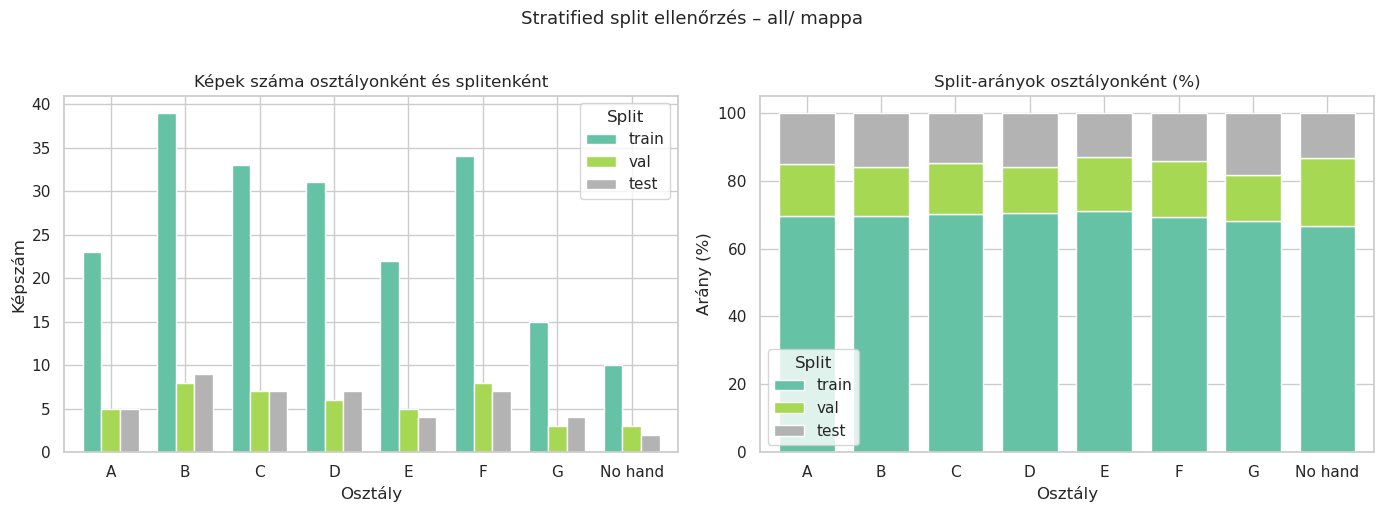

In [6]:
# ── Vizualizáció ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart – abszolút számok
pivot_plot = pivot.drop(columns=["össz"])
pivot_plot.plot(kind="bar", ax=axes[0], colormap="Set2", width=0.75)
axes[0].set_title("Képek száma osztályonként és splitenként", fontsize=12)
axes[0].set_xlabel("Osztály")
axes[0].set_ylabel("Képszám")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Split")

# Stacked bar – %-os arányok
pivot_pct = pivot_plot.div(pivot_plot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2", width=0.75)
axes[1].set_title("Split-arányok osztályonként (%)", fontsize=12)
axes[1].set_xlabel("Osztály")
axes[1].set_ylabel("Arány (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Split")

plt.suptitle("Stratified split ellenőrzés – all/ mappa", fontsize=13, y=1.02)
plt.tight_layout()
save_figure(fig, 'split_check')
plt.show()

<a id='6'></a>
## 6. Összefoglaló és következő lépések

### Mit értünk el?
- ✅ Reprodukálható 70/15/15 stratified split az `all/` mappából
- ✅ `data/split_manifest.csv` – egyetlen igazságforrás a pipeline számára
- ✅ G és No hand osztályok is jelen vannak minden splitben
- ✅ Eredeti fájlstruktúra érintetlen

### Következő lépések (`03_preprocessing.ipynb`)
Az összes következő notebook a manifestből olvas:

```python
manifest = pd.read_csv("data/split_manifest.csv")
train_df = manifest[manifest["split"] == "train"]
val_df   = manifest[manifest["split"] == "val"]
test_df  = manifest[manifest["split"] == "test"]
```

**Döntési pontok a preprocessing fázishoz:**

| # | Kérdés | Ajánlás |
|---|--------|---------|
| 1 | Célméret | 224×224 (ResNet/EfficientNet szabvány) |
| 2 | Csatornák | RGB (saját mean/std: R≈0.51, G≈0.44, B≈0.42) |
| 3 | Augmentáció | RandomHorizontalFlip, ColorJitter, RandomRotation(±15°) |
| 4 | Class weight | Igen – E és G osztályok alulreprezentáltak |
| 5 | Framework | PyTorch + torchvision transforms |